In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. LOAD THE DATA

In [3]:
print("Loading datasets...")
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

Loading datasets...


Let's look at the first few rows of the True dataset

In [4]:
print("\n--- True News Sample ---")
print(true_df.head(2))


--- True News Sample ---
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   


2. LABELING

-Add the target column 'label'

-0 represents Real/True News, 1 represents Fake News

In [5]:
true_df['label'] = 0
fake_df['label'] = 1

3. MERGING

-Combine both datasets vertically (axis=0)

In [6]:
print("\nMerging datasets...")
df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)


Merging datasets...


-It is best practice to shuffle the data after merging 

-so the model doesn't train on all true news first, then all fake news.

In [7]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

4. CLEANING & EDA

In [8]:
print("\n--- Dataset Structure ---")
# df.info() tells us data types and total row/column counts
df.info()
print("\n--- Missing Values Check ---")


--- Dataset Structure ---
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

--- Missing Values Check ---


Check for any blank/null cells

In [9]:
null_counts = df.isnull().sum()
print(null_counts)

title      0
text       0
subject    0
date       0
label      0
dtype: int64


If there are missing values, drop those rows

In [10]:
if null_counts.sum() > 0:
    print("\nDropping missing values...")
    df = df.dropna()

print("\n--- Duplicates Check ---")


--- Duplicates Check ---


Check for exact duplicate rows

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows.")

Found 209 duplicate rows.


Remove duplicates to prevent model bias

In [12]:
if duplicate_count > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates(keep='first')

Removing duplicates...


5. VISUALIZE THE BALANCE

A balanced dataset (roughly equal 0s and 1s) is crucial for an accurate model.

In [13]:
print("\nPlotting class balance...")

plt.figure(figsize=(8, 5))


Plotting class balance...


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

Use seaborn to create a bar chart of the labels

C:\Users\mayur\AppData\Local\Temp\ipykernel_19044\4084259364.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette=['#1f77b4', '#d62728'])


([<matplotlib.axis.XTick at 0x1f701216180>,
 [Text(0, 0, 'True News (0)'), Text(1, 0, 'Fake News (1)')])

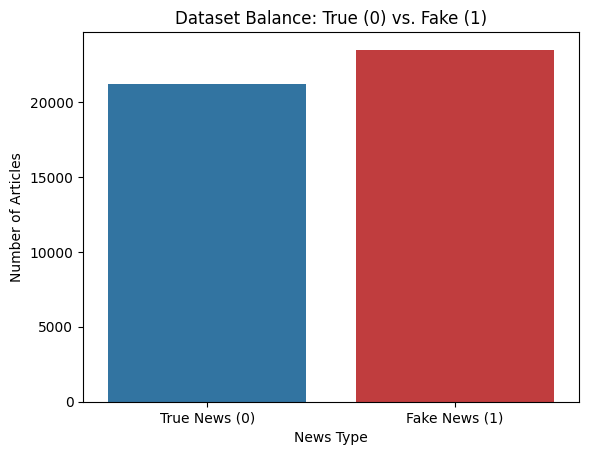

In [14]:
sns.countplot(data=df, x='label', palette=['#1f77b4', '#d62728'])

plt.title('Dataset Balance: True (0) vs. Fake (1)')
plt.xlabel('News Type')
plt.ylabel('Number of Articles')
plt.xticks(ticks=[0, 1], labels=['True News (0)', 'Fake News (1)'])

Display the plot

In [15]:
plt.show()

Final check of our clean dataset shape

In [16]:
print(f"\nFinal dataset ready for NLP preprocessing. Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")


Final dataset ready for NLP preprocessing. Total rows: 44689, Total columns: 5


Save the cleaned and merged data to a new CSV file

index=False prevents pandas from saving the row numbers as a column

In [17]:
df.to_csv('cleaned_news_data.csv', index=False)

print("Cleaned data saved successfully as 'cleaned_news_data.csv'!")

Cleaned data saved successfully as 'cleaned_news_data.csv'!
